<a href="https://colab.research.google.com/github/abdulabc23/superstore-sales-analysis/blob/main/superstore_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Superstore Sales Dataset   Data Analysis

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Import Success")

Import Success


In [94]:
# Load Data set.

In [95]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/superstore-sales-analysis/data/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [97]:
print(df.shape)

(9800, 18)


In [98]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [99]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [100]:
region = df['Region'].unique()
category = df['Category'].unique()
segment = df['Segment'].unique()
shipmode = df['Ship Mode'].unique()

In [101]:
df["Sales"].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [102]:
Total_Sales = df["Sales"].sum()
print(Total_Sales)

2261536.7827000003


#EDA

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


/tmp/ipykernel_304/2340670851.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Sales_by_category.index , y=Sales_by_category.values , palette="rainbow")


Text(0, 0.5, 'Sales')

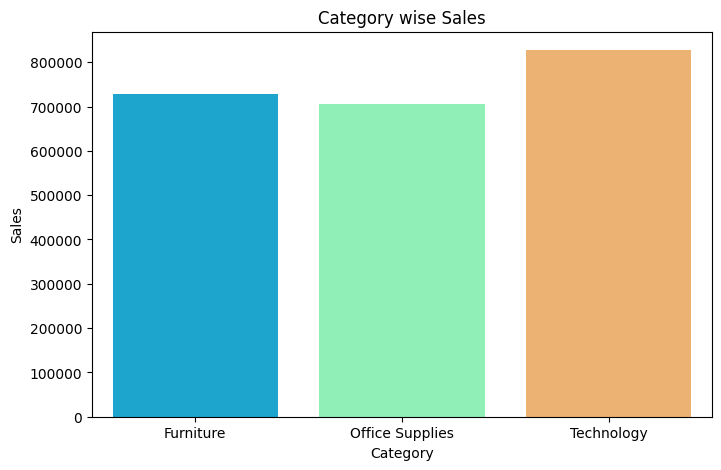

In [103]:
# Which category generates the most sales?
Sales_by_category = df.groupby("Category")["Sales"].sum()
print(Sales_by_category)
plt.figure(figsize=(8,5))
sns.barplot(x = Sales_by_category.index , y=Sales_by_category.values , palette="rainbow")
plt.title("Category wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

Sales By Region.

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


/tmp/ipykernel_304/2651480698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Sales_by_region.index , y = Sales_by_region.values , palette="rainbow")


<Axes: xlabel='Region'>

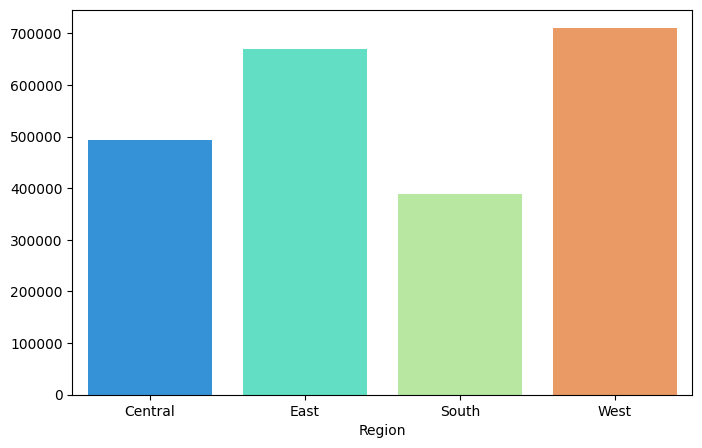

In [104]:
Sales_by_region = df.groupby("Region")["Sales"].sum()
print(Sales_by_region)
plt.figure(figsize=(8,5))
sns.barplot(x = Sales_by_region.index , y = Sales_by_region.values , palette="rainbow")

Top 10 best-selling products (this is a classic data analyst task).

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


<Axes: ylabel='Product Name'>

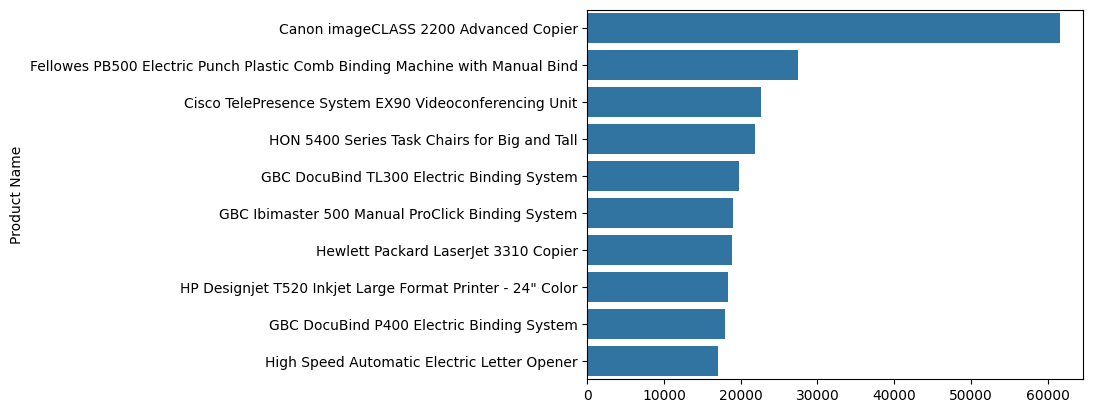

In [105]:
highest_sales_product = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(highest_sales_product)
sns.barplot(x = highest_sales_product.values  , y = highest_sales_product.index)

Now analysis by Time Series

In [106]:
# Convert date columns datatype from object to date
df['Order Date']= pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']= pd.to_datetime(df['Ship Date'], dayfirst=True)

In [107]:
# Feature engineering order Date
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


/tmp/ipykernel_304/2526949090.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = sales_by_year.index , y = sales_by_year.values , marker = 'o' , palette="hls")


Text(0, 0.5, 'Sales')

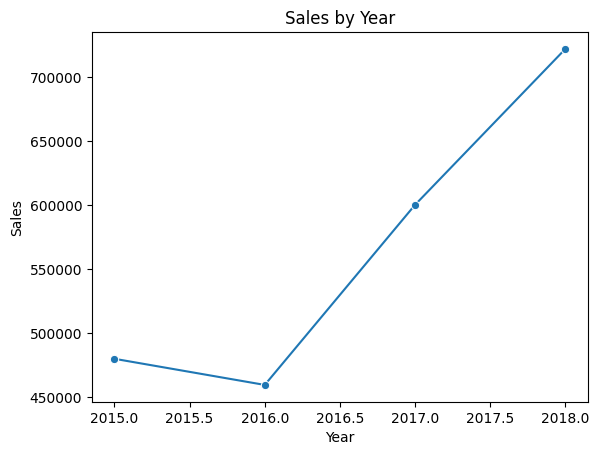

In [108]:
sales_by_year = df.groupby("Year")["Sales"].sum()
print(sales_by_year)
sns.lineplot(x = sales_by_year.index , y = sales_by_year.values , marker = 'o' , palette="hls")
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

Sa**les Heatmap (Category vs Region)**

Category    Furniture  Office Supplies  Technology
Region                                            
Central   160317.4622       163590.243  168739.208
East      206461.3880       199940.811  263116.527
South     116531.4800       124424.771  148195.208
West      245348.2455       217466.509  247404.930


<Axes: xlabel='Category', ylabel='Region'>

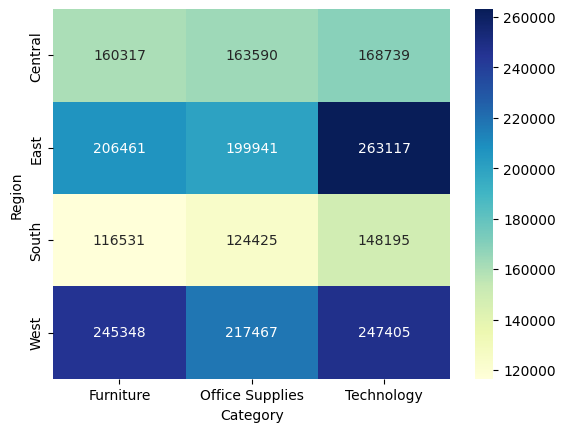

In [109]:
pivto = pd.pivot_table(df , values = "Sales" , index = "Region" , columns = "Category" , aggfunc = "sum")
print(pivto)
sns.heatmap(pivto , annot=True , fmt=".0f" , cmap="YlGnBu")

#Sales By Cites

/tmp/ipykernel_304/1204041837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Sales_by_cites.values , y =Sales_by_cites.index , palette="hls")


<Axes: ylabel='City'>

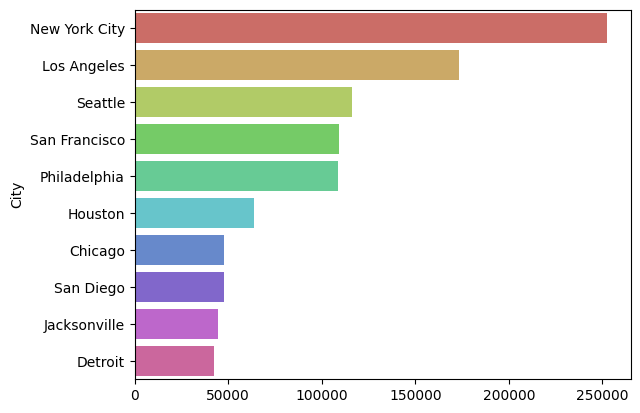

In [110]:
Sales_by_cites = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x = Sales_by_cites.values , y =Sales_by_cites.index , palette="hls")

/tmp/ipykernel_304/3551444297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Sales_by_cites.values , y =Sales_by_cites.index , palette="hls")


<Axes: ylabel='City'>

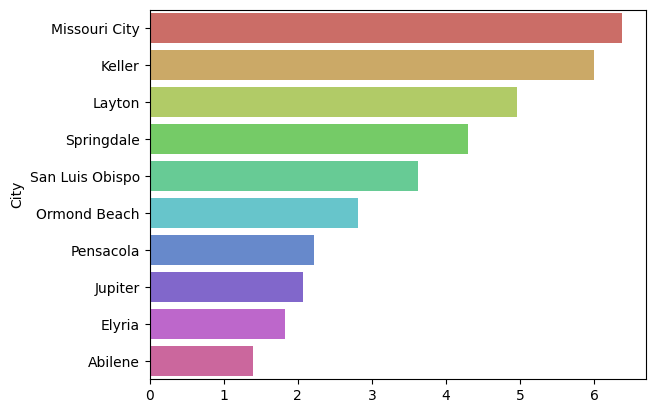

In [111]:
# Sales by cites where improvement needed.
Sales_by_cites = df.groupby("City")["Sales"].sum().sort_values(ascending=False).tail(10)
sns.barplot(x = Sales_by_cites.values , y =Sales_by_cites.index , palette="hls")

#Sales By segment

Which customer segment generates the most revenue?

/tmp/ipykernel_304/2133911440.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = Sales_by_Segment.index , y = Sales_by_Segment.values , palette="hls")


<Axes: xlabel='Segment'>

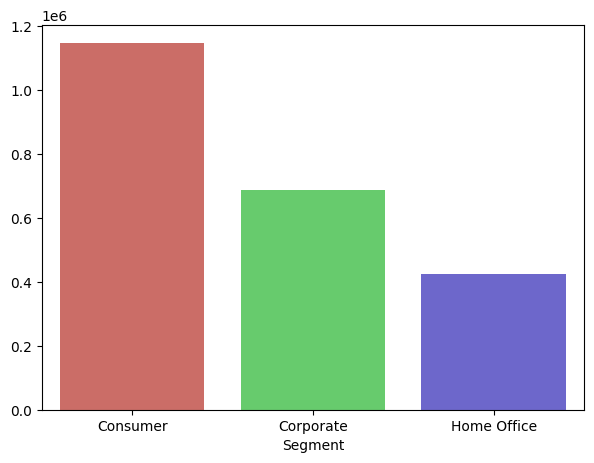

In [112]:
Sales_by_Segment = df.groupby("Segment")["Sales"].sum()
plt.figure(figsize=(7,5))
sns.barplot(x = Sales_by_Segment.index , y = Sales_by_Segment.values , palette="hls")

/tmp/ipykernel_304/2297907839.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Sales_by_Sub_Category.values , y=Sales_by_Sub_Category.index , palette="hls")


Text(0, 0.5, 'Sub-Category')

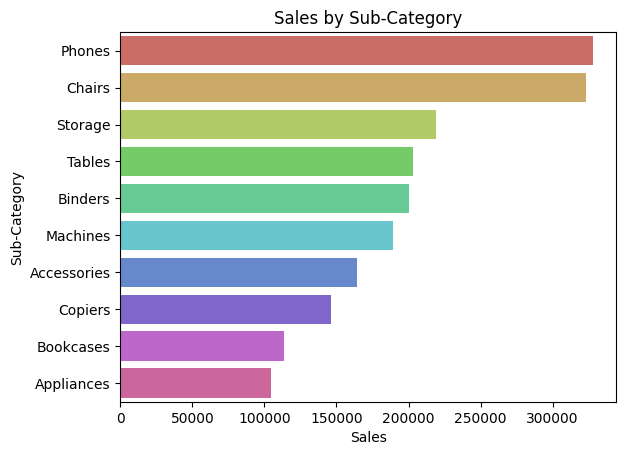

In [114]:
# Sales by sub_Category
Sales_by_Sub_Category = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=Sales_by_Sub_Category.values , y=Sales_by_Sub_Category.index , palette="hls")
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

/tmp/ipykernel_304/4147946224.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df["Sales"] , bins=100 ,palette="rainbow")


<Axes: xlabel='Sales', ylabel='Count'>

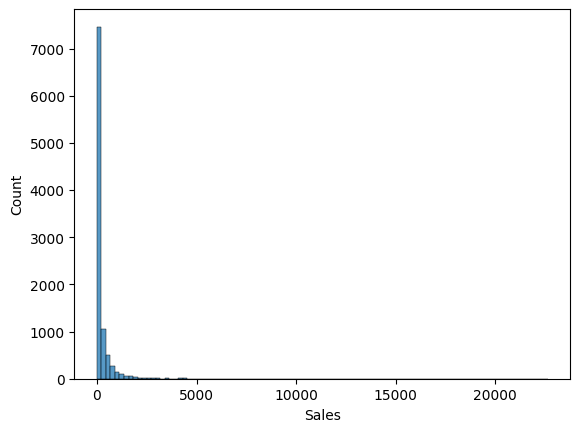

In [119]:
# Sales Distribution Histogram
sns.histplot(df["Sales"] , bins=100 ,palette="rainbow")